In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def compute_histogram(image):
    hist = np.bincount(image.ravel(), minlength=256)
    return hist

In [3]:
def otsu_threshold(image):
    hist = compute_histogram(image)
    total = image.size
    sum_all = np.dot(np.arange(256), hist)
    
    max_variance = 0.0
    optimal_thresh = 0
    
    w_b = 0.0      
    sum_b = 0.0    
    
    for t in range(256):
        w_b += hist[t]
        if w_b == 0:
            continue
            
        w_f = total - w_b  
        if w_f == 0:
            break
            
        sum_b += t * hist[t]
        
        mu_b = sum_b / w_b
        mu_f = (sum_all - sum_b) / w_f
        
        variance_between = w_b * w_f * (mu_b - mu_f) ** 2
        
        if variance_between > max_variance:
            max_variance = variance_between
            optimal_thresh = t
            best_wb = w_b
            best_wf = w_f
            best_mub = mu_b
            best_muf = mu_f
            
    print(f"--- Optimal threshold information (Threshold = {optimal_thresh}) ---")
    print(f"Background class weight (W_b): {best_wb}")
    print(f"Foreground class weight (W_f): {best_wf}")
    print(f"Background mean (Mu_b): {best_mub:.2f}")
    print(f"Foreground mean (Mu_f): {best_muf:.2f}")
    print(f"Maximum interclass variance: {max_variance:.2f}")
    
    return optimal_thresh

In [4]:
def global_threshold(image, threshold_value): 
    binary_image = np.where(image > threshold_value, 255, 0).astype(np.uint8)
    return binary_image

In [5]:
def apply_adaptive_methods(image, block_sizes=[11, 21, 31, 51]):
    results = {}
    C_value = 2  
    
    for block_size in block_sizes:
        mean_thresh = cv2.adaptiveThreshold(
            image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
            cv2.THRESH_BINARY, block_size, C_value
        )
        
        gauss_thresh = cv2.adaptiveThreshold(
            image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY, block_size, C_value
        )
        
        results[f'Mean_{block_size}'] = mean_thresh
        results[f'Gaussian_{block_size}'] = gauss_thresh
        
    return results

In [7]:
def plot_comparison(original, title, otsu_thresh_img, manual_thresh_img, adaptive_dict, block_size=51):
    plt.figure(figsize=(16, 10))
    plt.suptitle(title, fontsize=18)
    
    plt.subplot(2, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.imshow(otsu_thresh_img, cmap='gray')
    plt.title('Otsu Threshold')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.imshow(manual_thresh_img, cmap='gray')
    plt.title('Global Manual Threshold')
    plt.axis('off')
    
    plt.subplot(2, 3, 4)
    plt.imshow(adaptive_dict[f'Mean_{block_size}'], cmap='gray')
    plt.title(f'Adaptive Mean (Block: {block_size})')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(adaptive_dict[f'Gaussian_{block_size}'], cmap='gray')
    plt.title(f'Adaptive Gaussian (Block: {block_size})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


Processing 1A.jpeg...
--- Optimal threshold information (Threshold = 138) ---
Background class weight (W_b): 212509.0
Foreground class weight (W_f): 1476491.0
Background mean (Mu_b): 98.77
Foreground mean (Mu_f): 178.38
Maximum interclass variance: 1988431116189725.00


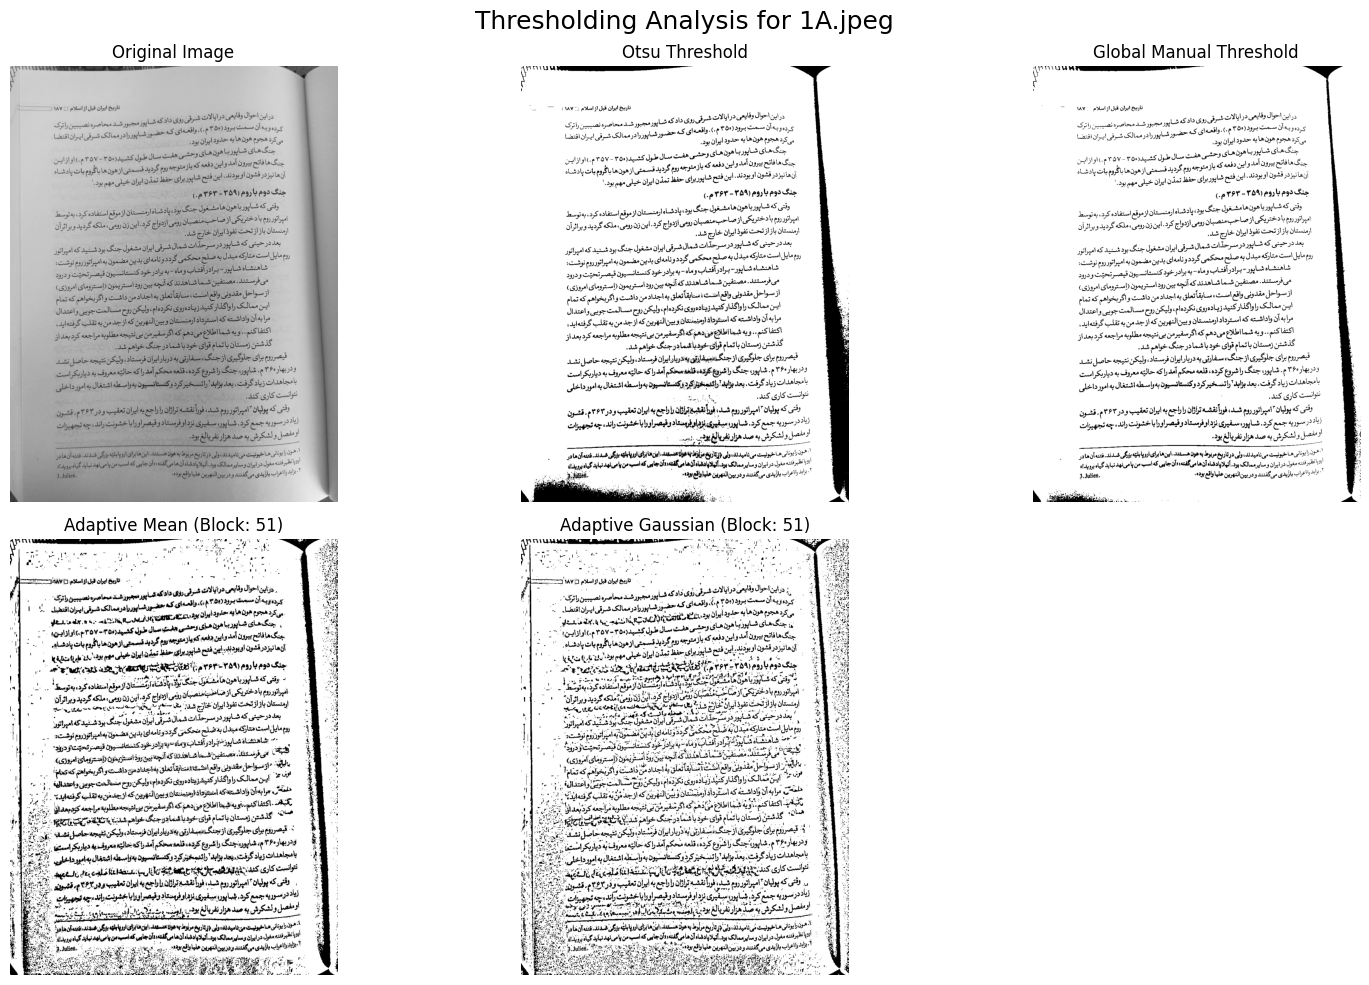


Processing 1B.jpeg...
--- Optimal threshold information (Threshold = 130) ---
Background class weight (W_b): 1050731.0
Foreground class weight (W_f): 638269.0
Background mean (Mu_b): 96.44
Foreground mean (Mu_f): 164.62
Maximum interclass variance: 3117973700516924.00


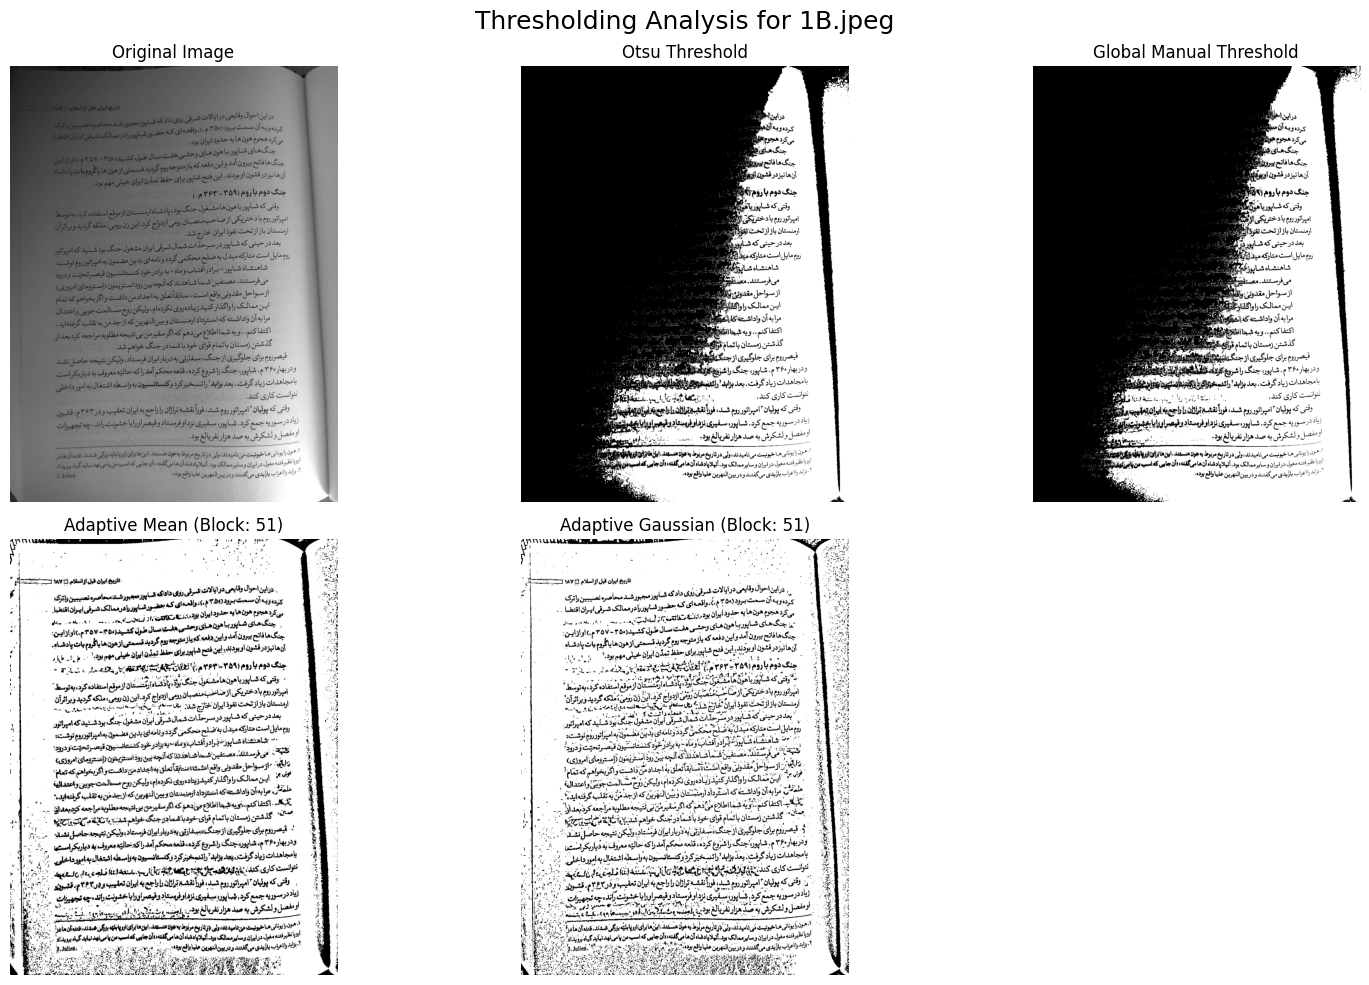

In [32]:
image_files = ['1A.jpeg', '1B.jpeg']

for filename in image_files:
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Error loading {filename}. Please check the path.")
        continue
        
    print(f"\n{'='*40}")
    print(f"Processing {filename}...")
    
    opt_thresh = otsu_threshold(img)
    
    otsu_result = global_threshold(img, opt_thresh)
    
    manual_result = global_threshold(img, 127)
    
    adaptive_results = apply_adaptive_methods(img, block_sizes=[11, 21, 31, 51])
    
    plot_comparison(
        original=img, 
        title=f"Thresholding Analysis for {filename}", 
        otsu_thresh_img=otsu_result, 
        manual_thresh_img=manual_result, 
        adaptive_dict=adaptive_results,
        block_size=51
    )

In [ ]:
img_clean = cv2.imread('1C.jpeg', cv2.IMREAD_GRAYSCALE)

if img_clean is None:
    raise FileNotFoundError("Image 1C.jpeg was not found. Make sure it is in the same directory as the notebook.")


def add_gaussian_noise(image, mean=0, sigma=10):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image.astype(np.float32) + noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


<div dir="rtl" style="font-family: IRANSans; line-height: 2; text-align: justify;">

## Dice Score و IoU چیستند؟

برای ارزیابی کیفیت بخش‌بندی تصویر، از معیارهایی استفاده می‌شود که میزان شباهت بین خروجی الگوریتم و تصویر مرجع را اندازه‌گیری کنند.  
دو معیار پرکاربرد در این زمینه **Dice Score** و **IoU (Intersection over Union)** هستند.

---

### 1) Dice Score

Dice Score میزان هم‌پوشانی بین دو ناحیه را اندازه‌گیری می‌کند.  
اگر ناحیه‌ی پیش‌بینی‌شده را با $A$ و ناحیه‌ی مرجع را با $B$ نشان دهیم، فرمول Dice به صورت زیر است:

$$
Dice = \frac{2 \cdot |A \cap B|}{|A| + |B|}
$$

در این رابطه:

- $|A \cap B|$ تعداد پیکسل‌هایی است که هم در خروجی الگوریتم و هم در تصویر مرجع به عنوان ناحیه‌ی هدف شناسایی شده‌اند.
- $|A|$ تعداد پیکسل‌های ناحیه‌ی هدف در خروجی الگوریتم است.
- $|B|$ تعداد پیکسل‌های ناحیه‌ی هدف در تصویر مرجع است.

**تفسیر مقدار Dice:**
- اگر مقدار Dice برابر **1** باشد، یعنی دو ناحیه کاملاً یکسان هستند.
- اگر مقدار Dice برابر **0** باشد، یعنی هیچ هم‌پوشانی‌ای بین آن‌ها وجود ندارد.
- هرچه Dice به **1** نزدیک‌تر باشد، کیفیت بخش‌بندی بهتر است.

---

### 2) IoU (Intersection over Union)

IoU نیز معیار دیگری برای سنجش میزان شباهت بین ناحیه‌ی پیش‌بینی‌شده و ناحیه‌ی مرجع است.  
فرمول آن به صورت زیر است:

$$
IoU = \frac{|A \cap B|}{|A \cup B|}
$$

در اینجا:

- $|A \cap B|$ همان اشتراک دو ناحیه است.
- $|A \cup B|$ اجتماع دو ناحیه است، یعنی تمام پیکسل‌هایی که در حداقل یکی از دو ناحیه قرار دارند.

**تفسیر مقدار IoU:**
- مقدار **1** به معنی تطابق کامل است.
- مقدار **0** یعنی هیچ اشتراکی بین دو ناحیه وجود ندارد.
- هرچه IoU بزرگ‌تر باشد، عملکرد روش بخش‌بندی بهتر است.

---

### تفاوت Dice و IoU

هر دو معیار برای سنجش هم‌پوشانی استفاده می‌شوند، اما Dice معمولاً مقدار بزرگ‌تری نسبت به IoU می‌دهد و کمی نرم‌تر است.  
رابطه‌ی بین این دو معیار به صورت زیر است:

$$
Dice = \frac{2 \times IoU}{1 + IoU}
$$

و برعکس:

$$
IoU = \frac{Dice}{2 - Dice}
$$

---

### کاربرد در این آزمایش

در این آزمایش، پس از اعمال روش‌های مختلف آستانه‌گذاری روی تصویر نویزی، خروجی هر روش با تصویر مرجع مقایسه می‌شود.  
سپس با استفاده از **Dice Score** و **IoU** مشخص می‌شود که کدام روش در برابر افزایش نویز، پایداری بیشتری دارد.

هرچه مقدار این دو معیار در سطوح نویز بالاتر **کمتر افت کند**، آن روش مقاوم‌تر و پایدارتر است.
</div>

In [12]:
def dice_score(binary1, binary2):
    """
    Compute Dice coefficient between two binary images.
    
    In this notebook, thresholding produces:
        255 for background
        0 for foreground/text
    
    Therefore, we convert text pixels to True using image == 0.
    """
    mask1 = binary1 == 0
    mask2 = binary2 == 0
    
    intersection = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    
    if total == 0:
        return 1.0
    
    return 2 * intersection / total



def iou_score(binary1, binary2):
    """
    Compute Intersection over Union between two binary images.
    Text pixels are considered foreground.
    """
    mask1 = binary1 == 0
    mask2 = binary2 == 0
    
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    
    if union == 0:
        return 1.0
    
    return intersection / union


In [13]:
manual_threshold_value = 127
adaptive_block_size = 51

# Otsu reference
clean_otsu_thresh = otsu_threshold(img_clean)
ref_otsu = global_threshold(img_clean, clean_otsu_thresh)

# Global manual reference
ref_manual = global_threshold(img_clean, manual_threshold_value)

# Adaptive reference
clean_adaptive_results = apply_adaptive_methods(img_clean, block_sizes=[adaptive_block_size])
ref_adaptive_mean = clean_adaptive_results[f'Mean_{adaptive_block_size}']
ref_adaptive_gaussian = clean_adaptive_results[f'Gaussian_{adaptive_block_size}']


--- Optimal threshold information (Threshold = 145) ---
Background class weight (W_b): 214653.0
Foreground class weight (W_f): 1474347.0
Background mean (Mu_b): 90.88
Foreground mean (Mu_f): 200.05
Maximum interclass variance: 3771795977056297.50


In [28]:
noise_sigmas = [0,10,25,50]

dice_results = {
    'Otsu': [],
    'Global Manual': [],
    'Adaptive Mean': [],
    'Adaptive Gaussian': []
}

iou_results = {
    'Otsu': [],
    'Global Manual': [],
    'Adaptive Mean': [],
    'Adaptive Gaussian': []
}

np.random.seed(42)

for sigma in noise_sigmas:
    
    if sigma == 0:
        noisy_img = img_clean.copy()
    else:
        noisy_img = add_gaussian_noise(img_clean, mean=0, sigma=sigma)
    
    otsu_thresh = otsu_threshold(noisy_img)
    otsu_result = global_threshold(noisy_img, otsu_thresh)
    
    manual_result = global_threshold(noisy_img, manual_threshold_value)
    
    adaptive_results = apply_adaptive_methods(noisy_img, block_sizes=[adaptive_block_size])
    adaptive_mean_result = adaptive_results[f'Mean_{adaptive_block_size}']
    adaptive_gaussian_result = adaptive_results[f'Gaussian_{adaptive_block_size}']

    dice_results['Otsu'].append(dice_score(ref_otsu, otsu_result))
    dice_results['Global Manual'].append(dice_score(ref_manual, manual_result))
    dice_results['Adaptive Mean'].append(dice_score(ref_adaptive_mean, adaptive_mean_result))
    dice_results['Adaptive Gaussian'].append(dice_score(ref_adaptive_gaussian, adaptive_gaussian_result))
    
    iou_results['Otsu'].append(iou_score(ref_otsu, otsu_result))
    iou_results['Global Manual'].append(iou_score(ref_manual, manual_result))
    iou_results['Adaptive Mean'].append(iou_score(ref_adaptive_mean, adaptive_mean_result))
    iou_results['Adaptive Gaussian'].append(iou_score(ref_adaptive_gaussian, adaptive_gaussian_result))


--- Optimal threshold information (Threshold = 145) ---
Background class weight (W_b): 214653.0
Foreground class weight (W_f): 1474347.0
Background mean (Mu_b): 90.88
Foreground mean (Mu_f): 200.05
Maximum interclass variance: 3771795977056297.50
--- Optimal threshold information (Threshold = 148) ---
Background class weight (W_b): 244093.0
Foreground class weight (W_f): 1444907.0
Background mean (Mu_b): 96.19
Foreground mean (Mu_f): 200.68
Maximum interclass variance: 3851147182904209.50
--- Optimal threshold information (Threshold = 162) ---
Background class weight (W_b): 427226.0
Foreground class weight (W_f): 1261774.0
Background mean (Mu_b): 116.85
Foreground mean (Mu_f): 208.07
Maximum interclass variance: 4485619914013374.00
--- Optimal threshold information (Threshold = 167) ---
Background class weight (W_b): 607908.0
Foreground class weight (W_f): 1081092.0
Background mean (Mu_b): 116.05
Foreground mean (Mu_f): 218.88
Maximum interclass variance: 6949850076874803.00


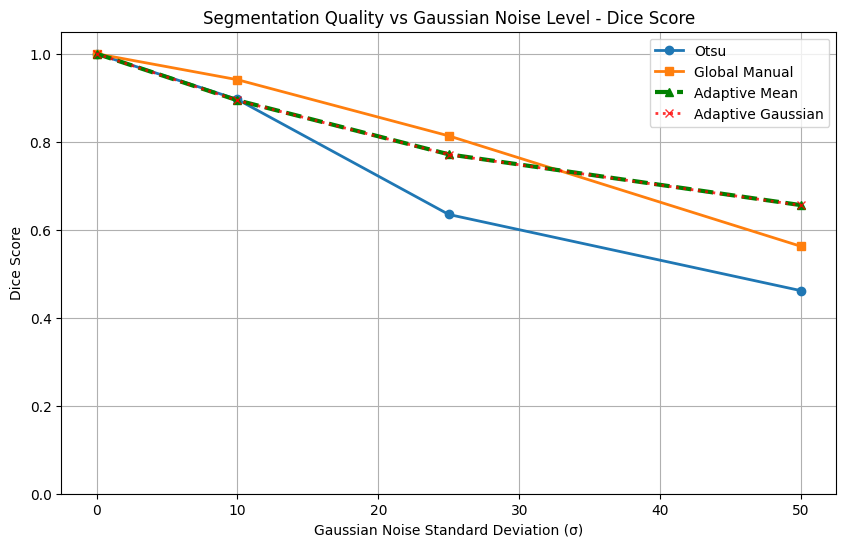

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(noise_sigmas, dice_results['Otsu'],
         marker='o', linewidth=2, label='Otsu')

plt.plot(noise_sigmas, dice_results['Global Manual'],
         marker='s', linewidth=2, label='Global Manual')

plt.plot(noise_sigmas, dice_results['Adaptive Mean'],
         marker='^', linestyle='--', linewidth=3,
         color='green', label='Adaptive Mean', zorder=3)

plt.plot(noise_sigmas, dice_results['Adaptive Gaussian'],
         marker='x', linestyle=':', linewidth=2,
         color='red', alpha=0.8, label='Adaptive Gaussian', zorder=4)

plt.title('Segmentation Quality vs Gaussian Noise Level - Dice Score')
plt.xlabel('Gaussian Noise Standard Deviation (σ)')
plt.ylabel('Dice Score')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)
plt.show()


In [30]:
# ---------------------------------------
# Print numerical results
# ---------------------------------------
print("Dice Scores:")
print("--------------------------------------")
for method_name, scores in dice_results.items():
    print(method_name)
    for sigma, score in zip(noise_sigmas, scores):
        print(f"  Sigma = {sigma:2d}  --> Dice = {score:.4f}")
    print()

print("IoU Scores:")
print("--------------------------------------")
for method_name, scores in iou_results.items():
    print(method_name)
    for sigma, score in zip(noise_sigmas, scores):
        print(f"  Sigma = {sigma:2d}  --> IoU = {score:.4f}")
    print()


Dice Scores:
--------------------------------------
Otsu
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8961
  Sigma = 25  --> Dice = 0.6347
  Sigma = 50  --> Dice = 0.4614

Global Manual
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.9410
  Sigma = 25  --> Dice = 0.8133
  Sigma = 50  --> Dice = 0.5622

Adaptive Mean
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8941
  Sigma = 25  --> Dice = 0.7714
  Sigma = 50  --> Dice = 0.6558

Adaptive Gaussian
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8938
  Sigma = 25  --> Dice = 0.7707
  Sigma = 50  --> Dice = 0.6553

IoU Scores:
--------------------------------------
Otsu
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8117
  Sigma = 25  --> IoU = 0.4648
  Sigma = 50  --> IoU = 0.2999

Global Manual
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8885
  Sigma = 25  --> IoU = 0.6853
  Sigma = 50  --> IoU = 0.3910

Adaptive Mean
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --

--- Optimal threshold information (Threshold = 145) ---
Background class weight (W_b): 214653.0
Foreground class weight (W_f): 1474347.0
Background mean (Mu_b): 90.88
Foreground mean (Mu_f): 200.05
Maximum interclass variance: 3771795977056297.50


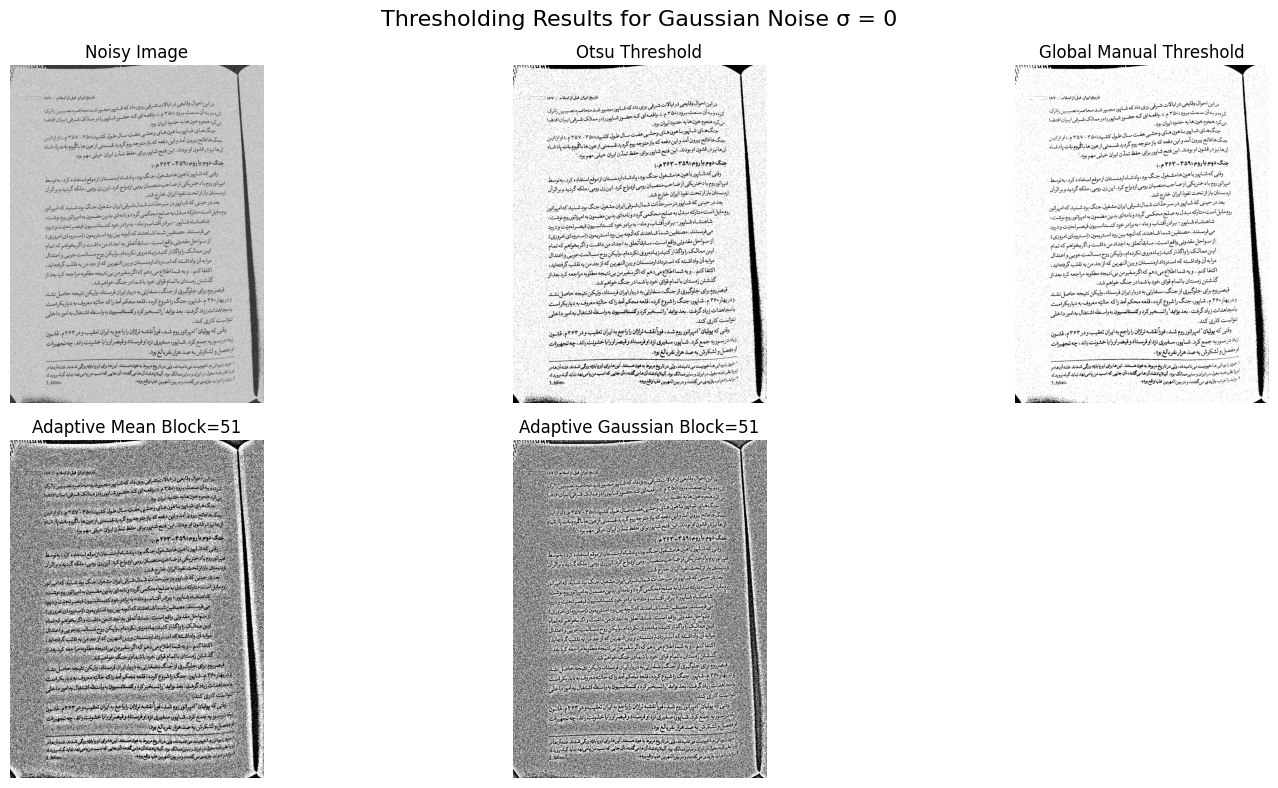

--- Optimal threshold information (Threshold = 148) ---
Background class weight (W_b): 244292.0
Foreground class weight (W_f): 1444708.0
Background mean (Mu_b): 96.18
Foreground mean (Mu_f): 200.71
Maximum interclass variance: 3856213240199854.00


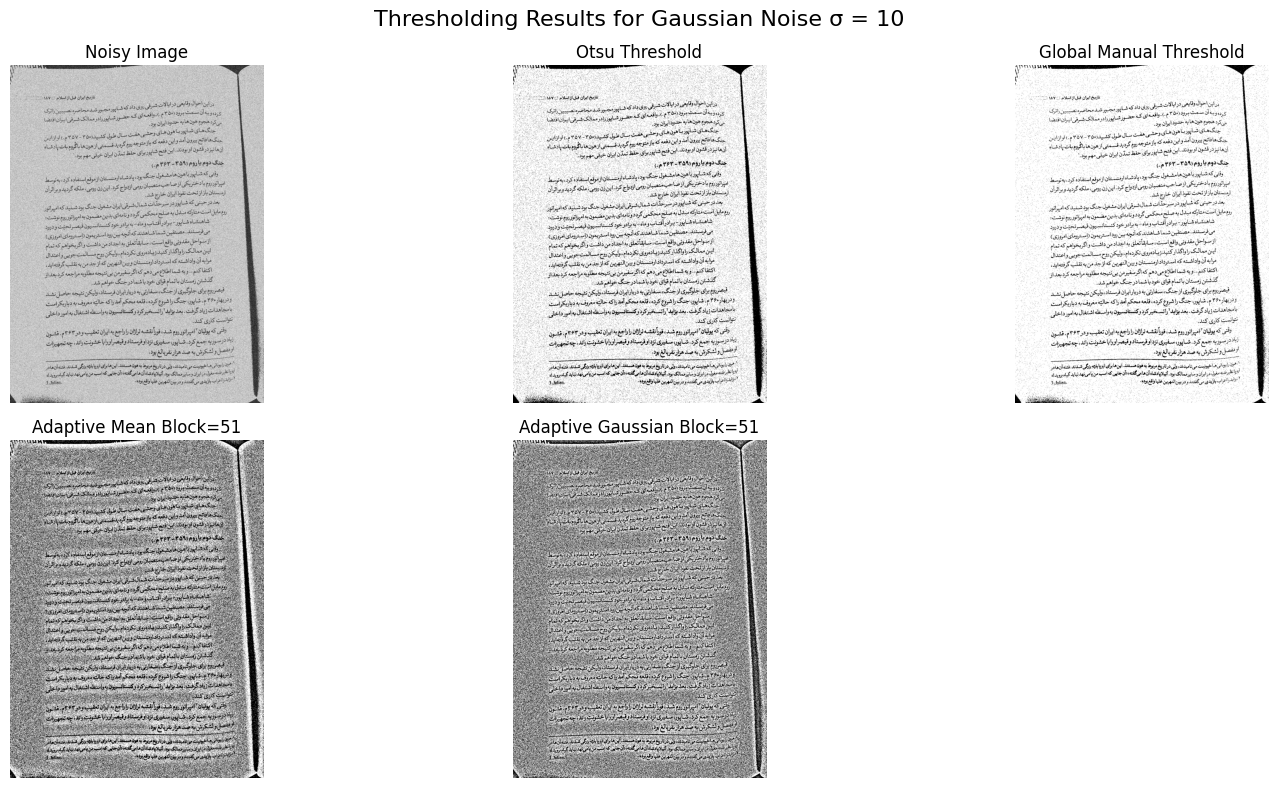

--- Optimal threshold information (Threshold = 162) ---
Background class weight (W_b): 427275.0
Foreground class weight (W_f): 1261725.0
Background mean (Mu_b): 116.84
Foreground mean (Mu_f): 208.07
Maximum interclass variance: 4487064468744565.50


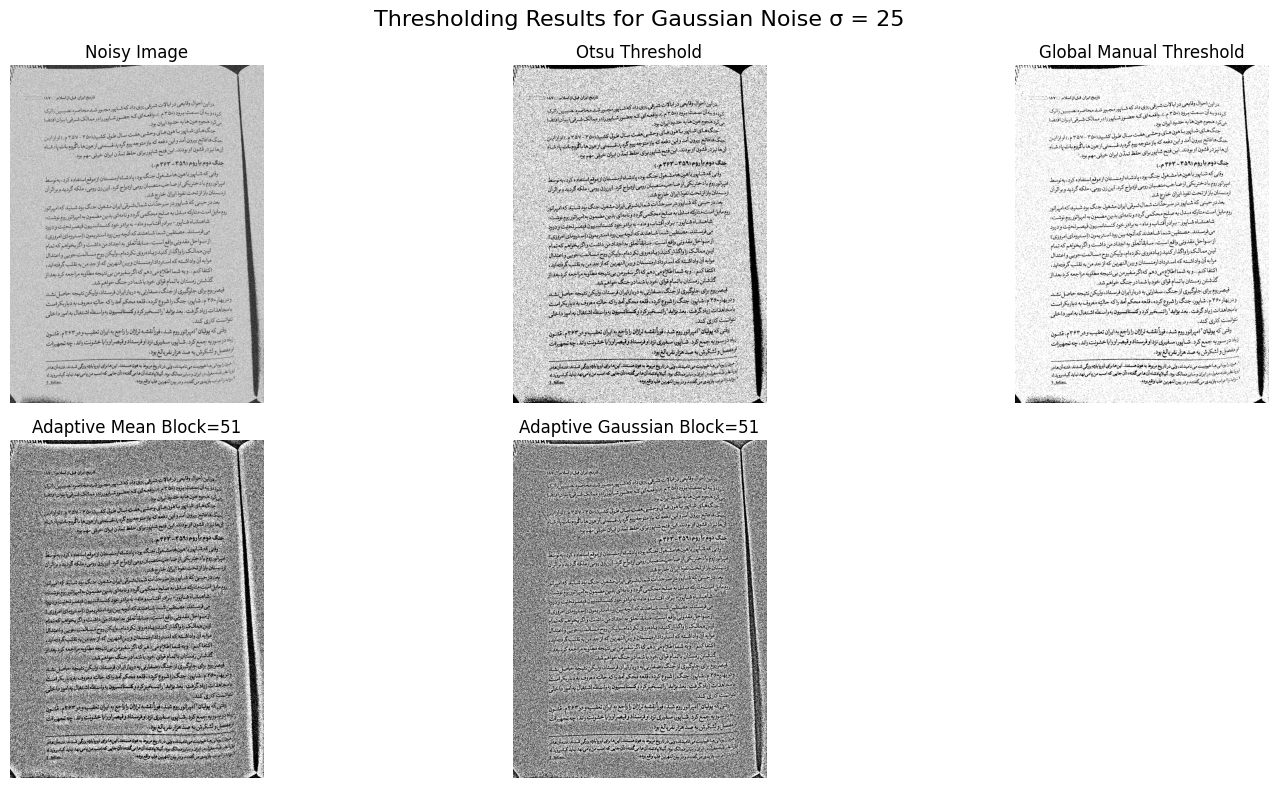

--- Optimal threshold information (Threshold = 167) ---
Background class weight (W_b): 608889.0
Foreground class weight (W_f): 1080111.0
Background mean (Mu_b): 116.04
Foreground mean (Mu_f): 218.92
Maximum interclass variance: 6960114757912250.00


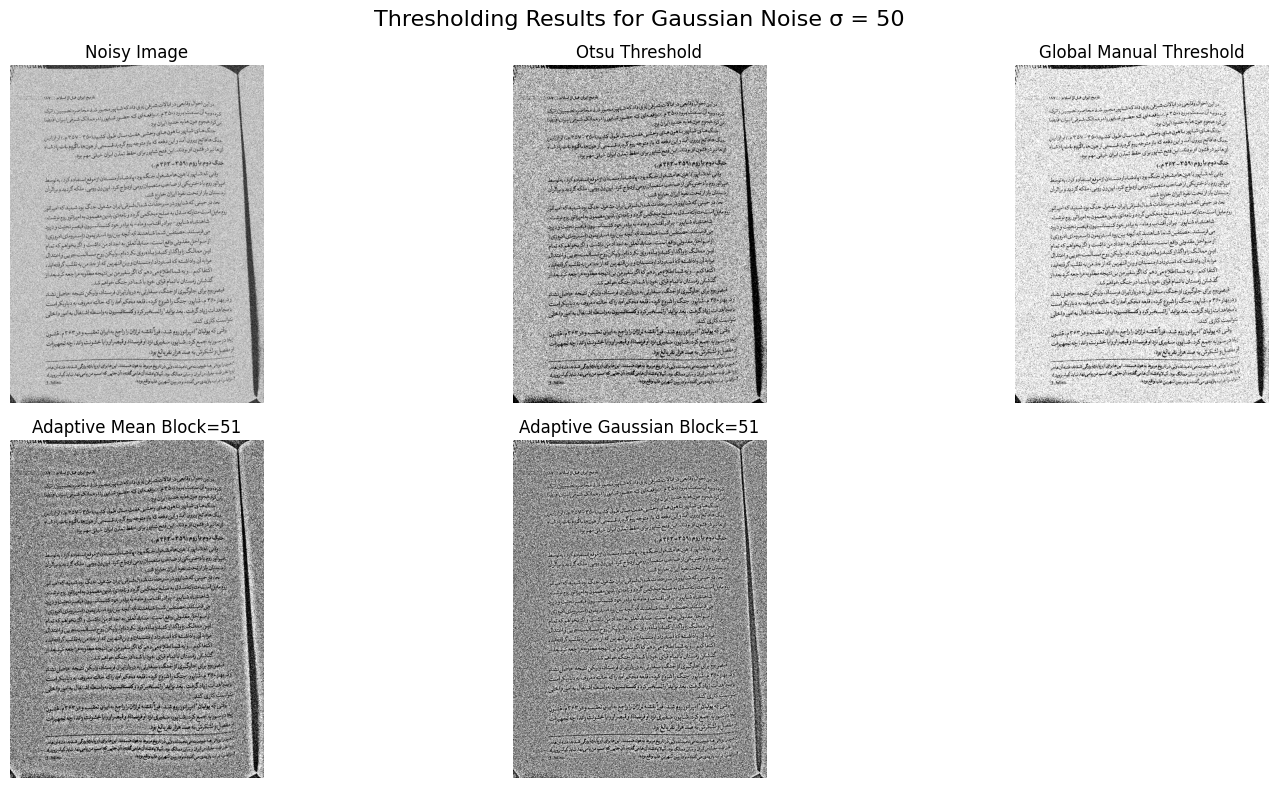

In [ ]:
selected_sigmas = [0,10,25,50]

for sigma in selected_sigmas:
    
    if sigma == 0:
        noisy_img = img_clean.copy()
    else:
        noisy_img = add_gaussian_noise(img_clean, mean=0, sigma=sigma)
    
    otsu_thresh = otsu_threshold(noisy_img)
    otsu_result = global_threshold(noisy_img, otsu_thresh)
    
    manual_result = global_threshold(noisy_img, manual_threshold_value)
    
    adaptive_results = apply_adaptive_methods(noisy_img, block_sizes=[adaptive_block_size])
    adaptive_mean_result = adaptive_results[f'Mean_{adaptive_block_size}']
    adaptive_gaussian_result = adaptive_results[f'Gaussian_{adaptive_block_size}']
    
    plt.figure(figsize=(16, 8))
    plt.suptitle(f'Thresholding Results for Gaussian Noise σ = {sigma}', fontsize=16)
    
    plt.subplot(2, 3, 1)
    plt.imshow(noisy_img, cmap='gray')
    plt.title('Noisy Image')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.imshow(otsu_result, cmap='gray')
    plt.title('Otsu Threshold')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.imshow(manual_result, cmap='gray')
    plt.title('Global Manual Threshold')
    plt.axis('off')
    
    plt.subplot(2, 3, 4)
    plt.imshow(adaptive_mean_result, cmap='gray')
    plt.title(f'Adaptive Mean Block={adaptive_block_size}')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(adaptive_gaussian_result, cmap='gray')
    plt.title(f'Adaptive Gaussian Block={adaptive_block_size}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


<div dir="rtl" style="font-family: IRANSans,sans-serif; line-height: 2; font-size: 16px; text-align: justify;">

<h3>تصویر A ـ شرایط نوری یکنواخت</h3>

<p>
در تصویر <b>1A</b>، بهترین عملکرد مربوط به <b>Global Manual Threshold</b>  است؛
روش <b>آستانه‌گذاری سراسری اتسو (Otsu)</b> نیز نتیجه‌ای بسیار نزدیک دارد.
</p>

<p><b>دلیل:</b></p>
<ul>
  <li>در این تصویر روشنایی صفحه تقریباً یکنواخت است.</li>
  <li>پس‌زمینه‌ی کاغذ و متن، دو کلاس نسبتاً جدا از هم تشکیل می‌دهند.</li>
  <li>بنابراین هیستوگرام تصویر تقریباً دو قله‌ای است: یک قله برای پس‌زمینه‌ی روشن و یک قله برای متن تیره.</li>
  <li>روش اتسو دقیقاً برای چنین حالتی مناسب است، چون آستانه‌ای را انتخاب می‌کند که واریانس درون‌کلاسی را کمینه و جدایی بین متن و پس‌زمینه را بیشینه کند.</li>
</ul>

<p>در خروجی تصویر A مشاهده می‌شود که:</p>
<ul>
  <li>متن‌ها نسبتاً خوب حفظ شده‌اند.</li>
  <li>پس‌زمینه سفید و تمیز باقی مانده است.</li>
  <li>نویز و لکه‌های اضافی کم است.</li>
</ul>

<p>
در مقابل، روش‌های <b>Adaptive Mean</b> و <b>Adaptive Gaussian</b> اگرچه متن را حفظ می‌کنند،
اما در نواحی سفید صفحه لکه‌ها و نویزهای بیشتری تولید کرده‌اند. چون در آستانه‌گذاری تطبیقی،
تصمیم‌گیری بر اساس همسایگی محلی انجام می‌شود و تغییرات جزئی بافت کاغذ یا سایه‌های خفیف
می‌توانند به‌اشتباه به عنوان متن تشخیص داده شوند.
</p>

<p>
<b>نتیجه برای تصویر A:</b><br>
بهترین روش: <b>Otsu Threshold</b> یا <b>Global Manual Threshold</b> <br>
چون نور یکنواخت است و جدایی شدت روشنایی متن و زمینه به‌صورت سراسری امکان‌پذیر است.
</p>

<hr>

<h3>تصویر B ـ شرایط نوری غیریکنواخت</h3>

<p>
در تصویر <b>1B</b>، روش اتسو عملکرد ضعیفی دارد.
</p>

<p>
در تصویر اصلی، روشنایی صفحه یکنواخت نیست. سمت چپ تصویر تاریک‌تر است و در سمت راست،
ناحیه‌ای روشن‌تر وجود دارد. همچنین در نزدیکی لبه‌ی راست و پایین صفحه، تغییرات شدید روشنایی
و سایه دیده می‌شود.
</p>

<p>
روش اتسو از یک <b>آستانه‌ی سراسری واحد</b> برای کل تصویر استفاده می‌کند.
این فرض زمانی درست است که شدت روشنایی پس‌زمینه در تمام تصویر تقریباً ثابت باشد،
اما در تصویر B این شرط برقرار نیست.
</p>

<h4>چرا اتسو در تصویر B شکست می‌خورد؟</h4>

<p>در تصویر B، شدت روشنایی پس‌زمینه در نواحی مختلف متفاوت است:</p>
<ul>
  <li>در <b>سمت چپ صفحه</b>، پس‌زمینه به علت سایه، تیره‌تر شده است.</li>
  <li>در <b>سمت راست صفحه</b>، پس‌زمینه روشن‌تر است.</li>
  <li>در <b>پایین تصویر</b> نیز تغییرات روشنایی و سایه وجود دارد.</li>
</ul>

<p>
به همین دلیل، مقدار خاکستری پس‌زمینه‌ی تاریک در سمت چپ ممکن است به مقدار خاکستری متن
در نواحی روشن نزدیک شود. در نتیجه، هیستوگرام تصویر دیگر یک هیستوگرام دوکلاسی تمیز نیست
و کلاس‌های «متن» و «پس‌زمینه» با هم هم‌پوشانی پیدا می‌کنند.
</p>

<p>در خروجی Otsu برای تصویر B دیده می‌شود که:</p>
<ul>
  <li>بخش بزرگی از <b>سمت چپ تصویر</b> به اشتباه سیاه شده است.</li>
  <li>ناحیه‌ی تاریک پس‌زمینه به عنوان متن یا جسم پیش‌زمینه تشخیص داده شده است.</li>
  <li>در نواحی میانی و پایین سمت چپ، آستانه‌گذاری سراسری باعث از بین رفتن جزئیات متن یا ترکیب شدن متن با پس‌زمینه شده است.</li>
  <li>در سمت راست، به دلیل روشن‌تر بودن پس‌زمینه، نتیجه بهتر است؛ اما کل تصویر به طور یکنواخت بخش‌بندی نشده است.</li>
</ul>

<p>
علت اصلی این پدیده این است که اتسو فقط یک مقدار آستانه برای کل تصویر انتخاب می‌کند،
در حالی که تصویر به چند آستانه‌ی متفاوت در نواحی مختلف نیاز دارد.
</p>

<hr>

<h3>عملکرد آستانه‌گذاری تطبیقی در تصویر B</h3>

<p>
روش‌های <b>Adaptive Mean</b> و <b>Adaptive Gaussian</b> برای تصویر B عملکرد بهتری نسبت به اتسو دارند.
</p>

<p>
در آستانه‌گذاری تطبیقی، به جای استفاده از یک آستانه‌ی ثابت برای کل تصویر،
برای هر پیکسل یک آستانه‌ی محلی محاسبه می‌شود.
</p>

<p>برای مثال در روش Adaptive Mean:</p>

<div style="direction:ltr; text-align:center; margin: 12px 0; font-family: 'Times New Roman', serif;">
T(x,y) = mean(N<sub>x,y</sub>) - C
</div>

<p>که در آن:</p>
<ul>
  <li><b>N<sub>x,y</sub></b> همسایگی اطراف پیکسل است.</li>
  <li><b>mean</b> میانگین شدت روشنایی در آن ناحیه است.</li>
  <li><b>C</b> یک مقدار ثابت برای تنظیم حساسیت آستانه است.</li>
</ul>

<p>
در روش Adaptive Gaussian نیز به جای میانگین ساده، میانگین وزن‌دار گاوسی محاسبه می‌شود؛
یعنی پیکسل‌های نزدیک‌تر به مرکز وزن بیشتری دارند.
</p>

<h4>چرا آستانه‌گذاری تطبیقی مشکل را برطرف می‌کند؟</h4>

<ul>
  <li>در نواحی تاریک، آستانه محلی پایین‌تر می‌آید.</li>
  <li>در نواحی روشن، آستانه محلی بالاتر می‌رود.</li>
  <li>بنابراین متن در هر بخش نسبت به پس‌زمینه‌ی همان بخش مقایسه می‌شود، نه نسبت به کل تصویر.</li>
</ul>

<p>
به همین دلیل، در تصویر B روش‌های تطبیقی می‌توانند متن را در نواحی سایه‌دار بهتر حفظ کنند
و از سیاه شدن کل بخش تاریک صفحه جلوگیری کنند.
</p>

<p>
با این حال، در خروجی Adaptive Mean و Adaptive Gaussian مقداری نویز و لکه دیده می‌شود،
مخصوصاً در نواحی حاشیه و بافت کاغذ. علت آن این است که این روش‌ها به تغییرات محلی حساس‌اند.
</p>
</div>

<div dir="rtl" style="font-family: IRANSans">

# بخش C: تحلیل مقاومت در برابر نویز

## هدف
اضافه کردن نویز گاوسی با انحراف معیارهای متفاوت به یک تصویر بدون نویز و ارزیابی کیفیت بخش‌بندی تمام روش‌های آستانه‌گذاری با استفاده از نمرات Dice و IoU.

---

## خلاصه نتایج

### نمرات Dice:
```
Otsu
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8961
  Sigma = 25  --> Dice = 0.6347
  Sigma = 50  --> Dice = 0.4614

Global Manual
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.9410
  Sigma = 25  --> Dice = 0.8133
  Sigma = 50  --> Dice = 0.5622

Adaptive Mean
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8941
  Sigma = 25  --> Dice = 0.7714
  Sigma = 50  --> Dice = 0.6558

Adaptive Gaussian
  Sigma =  0  --> Dice = 1.0000
  Sigma = 10  --> Dice = 0.8938
  Sigma = 25  --> Dice = 0.7707
  Sigma = 50  --> Dice = 0.6553
```

### نمرات IoU:
```
Otsu
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8117
  Sigma = 25  --> IoU = 0.4648
  Sigma = 50  --> IoU = 0.2999

Global Manual
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8885
  Sigma = 25  --> IoU = 0.6853
  Sigma = 50  --> IoU = 0.3910

Adaptive Mean
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8086
  Sigma = 25  --> IoU = 0.6278
  Sigma = 50  --> IoU = 0.4879

Adaptive Gaussian
  Sigma =  0  --> IoU = 1.0000
  Sigma = 10  --> IoU = 0.8080
  Sigma = 25  --> IoU = 0.6269
  Sigma = 50  --> IoU = 0.4874
```

---

## تحلیل تفصیلی و توضیحات

### آستانه‌گذاریGlobal Manual: بیشترین مقاومت در برابر نویز

**رتبه‌بندی در سطوح مختلف نویز:**
- **بهترین مقاومت کلی در برابر نویز** 
- در Sigma = 10: Dice = 0.9410 (بیشترین در بین همه روش‌ها)
- در Sigma = 25: Dice = 0.8133 (بیشترین در بین همه روش‌ها)
- در Sigma = 50: Dice = 0.5622 (بیشترین در بین همه روش‌ها)

**چرا آستانه‌گذاری آستانه‌گذاریGlobal Manual بیشترین مقاومت را دارد:**

- **سادگی و پایداری**: آستانه ثابت (127) تحت تأثیر تغییرات محلی نویز نیست. این روش تلاش نمی‌کند تا خود را با ناحیه‌های پرنویز سازگار کند، که می‌تواند عدم ثبات در روش‌های تطبیقی ایجاد کند.

- **عدم محاسبه مجدد پارامترها**: برخلاف روش Otsu که آستانه بهینه برای تصویر پرنویز را مجدد محاسبه می‌کند، آستانه دستی ثابت می‌ماند. در حالی که Otsu تلاش می‌کند با نویز سازگار شود (احتمالاً تصمیمات نادرست می‌گیرد)، روش دستی نویز را به‌طور سیستماتیک نادیده می‌گیرد.

- **حساسیت کمتر به نوسانات شدت روشنایی**: روش‌های جهانی تحت تأثیر انفجارهای نویز تصادفی قرار نمی‌گیرند زیرا یک آستانه یکسان را به‌طور یکنواخت اعمال می‌کنند. روش‌های تطبیقی محلی را مجدد محاسبه می‌کنند و نویز می‌تواند آمار محلی آن‌ها را تحریف کند.

- **تعادل**: اگرچه در تصاویر بدون نویز عملکرد کامل دارد (Dice = 1.0)، اما در تصاویر بدون نویز عملکرد کمی کمتری نسبت به Otsu در نویز بسیار پایین دارد. با این‌حال، با افزایش نویز، این به مزیت تبدیل می‌شود—ثبات بر سازگاری غالب است که زمانی که آمار محلی فاسد شده است.

---

### روش‌های تطبیقی (میانگین و گاوسی): مقاومت متوسط در برابر نویز

**عملکرد:**
- Adaptive Mean: Dice in Sigma 50 = 0.6558
- Adaptive Gaussian: Dice in Sigma 50 = 0.6553
- عملکرد تقریباً یکسان (≈0.12% تفاوت)

**چرا عملکرد کمتری دارند:**

- **فساد آمار محلی**: آستانه‌گذاری تطبیقی بر آمار محلی محیط بستگی دارد. نویز گاوسی مستقیماً این میانگین‌ها و واریانس‌های محلی را تحریف می‌کند و محاسبات آستانه را غیر قابل‌اعتماد می‌سازد.

- **وابستگی به اندازه بلوک**: عملکرد تا حد زیادی به پارامتر اندازه بلوک بستگی دارد. بلوک‌های کوچک پرنویز هستند؛ بلوک‌های بزرگ ممکن است جزئیات محلی را از دست بدهند. هیچ‌کدام در تمام سطوح نویز بهینه نیست.

- **تقویت بازگشتی نویز**: زمانی که نویز وجود دارد، آستانه تطبیقی محلی می‌تواند با تنها چند پیکسل نویز بالا در محیط به‌طور قابل‌توجهی تغییر کند، که منجر به بخش‌بندی ناسازگار می‌شود.

- **بهتر از Otsu در نویز بالا**: با این‌حال، آن‌ها در Sigma = 50 به‌طور قابل‌توجهی بهتر از Otsu عمل می‌کنند (Dice: 0.6558 در مقابل 0.4614)، که نشان می‌دهد در مقایسه با روش‌های خودکار کاملاً جهانی مقاومت ذاتی دارند.

---

### روش Otsu: ضعیف‌ترین مقاومت در برابر نویز

**تنزل عملکرد:**
- Sigma = 10: Dice = 0.8961 (قابل‌قبول)
- Sigma = 25: Dice = 0.6347 (کاهش تیز)
- Sigma = 50: Dice = 0.4614 (بدترین عملکرد)

**چرا Otsu در نویز شکست می‌خورد:**

- **تحریف هیستوگرام**: روش Otsu بر اساس توزیع هیستوگرام بهینه‌سازی می‌کند. نویز گاوسی هیستوگرام را به‌طور قابل‌توجهی تحریف می‌کند و قله‌های و دره‌های جعلی ایجاد می‌کند که الگوریتم را گمراه می‌کند.

- **مسئله بهینه‌سازی جهانی**: الگوریتم آستانه‌ای را جستجو می‌کند که واریانس درون‌کلاسی را کمینه کند. نویز واریانس را به‌طور تصادفی در پیش‌زمینه و پس‌زمینه افزایش می‌دهد، که فرض‌های بهینه‌سازی را شکسته می‌سازد.

- **بیش‌تطبیق**: برخلاف آستانه دستی ثابت، Otsu برای تصویر پرنویز مجدد محاسبه می‌کند. این «سازگاری» با نویز در واقع یک نقطه ضعف است—آستانه‌هایی تولید می‌کند که برای نسخه پرنویز بهینه هستند، نه تصویر واقعی.

- **شیب تنزل تندترین**: IoU از 1.0 → 0.8117 → 0.4648 → 0.2999 می‌افتد که تندترین افت در بین همه روش‌ها است و نشان‌دهنده مقاومت بسیار ضعیف است.

---

## تحلیل عملکرد مقایسه‌ای

### نرخ تنزل نمره Dice (برای هر افزایش Sigma):

| روش | Σ=0 تا Σ=10 | Σ=10 تا Σ=25 | Σ=25 تا Σ=50 | مجموع تلفات |
|--------|-------------|------------|------------|-----------|
| Otsu | -0.0039 | -0.2614 | **-0.1733** | **-0.5386** |
| Global Manual | -0.0590 | -0.1277 | -0.2511 | -0.4378 |
| Adaptive Mean | -0.0059 | -0.1227 | -0.1156 | -0.3442 |
| Adaptive Gaussian | -0.0062 | -0.1231 | -0.1154 | -0.3447 |

**بینش کلیدی**: Adaptive Gaussian کاهش تدریجی‌تری نشان می‌دهد، که نشان‌دهنده تنزل ثابت به جای شکست فاجعه‌آمیز است.

---

</div>